# User Manual

`ethograph` is a GUI for visualizing and segmenting multimodal behavioural
recordings.

## Install

```bash
uv pip install "ethograph[gui,audio]" --python 3.12
```

Launch with `ethograph launch`, or the desktop shortcut. See
{doc}`installation` for detailed  instructions.

## Multimodal visualization

Ethograph allows you to visualize a number of different data modalities:

| Data | Shown as | File formats / loaders |
|------|----------|------------------------|
| **Video** | multi-panel video | `.mp4`, `.avi`, `.mov`, `.mkv` (via [pyav](https://pyav.org/docs/stable/) and [pynaviz](https://pynapple-org.github.io/pynaviz)) |
| **Pose / BoundingBox** | Overlay on video | `.h5`, `.csv`, `.slp` (DLC, SLEAP, LightningPose, ... via [movement](https://movement.neuroinformatics.dev)) |
| **Audio** | Waveform + spectrogram | `.wav`, `.mp3` (via [audioio](https://github.com/bendalab/audioio)) |
| **Electrophysiology** | Multi-channel trace | `.dat`, `.bin`, `.raw` via [phylib](https://github.com/cortex-lab/phylib), and {ref}`many more formats <target-ephys-formats>` via [Neo](https://neo.readthedocs.io) |
| **Spike-sorted units** | Raster / PSTH | [Kilosort](https://github.com/MouseLand/Kilosort) folder, `.nwb` file, {class}`pynapple.TsGroup` |
| **Features** | Line plots / heatmaps | Kinematics, firing rates, latent variables, model outputs, etc. |

Feature data can be loaded via three backends:
| Backend | Object | File format |
|---------|--------|-------------|
| **xarray** | {class}`xarray.Dataset` / {class}`~ethograph.io.trialtree.TrialTree` | `.nc` |
| **Pynapple** | {class}`~pynapple.Tsd` / {class}`~pynapple.TsdFrame` | `.npz` or folder |
| **NWB** | `.nwb` (loaded via {mod}`pynapple`) | `.nwb` |
| **numpy** | plain array | `.npy` |

Unlike a plain numpy array, the top three formats carry explicit timestamps with
each value. This allows `ethograph` to automatically align data of different
sampling rates and modalities (video, audio & electrophysiology).

```{note}
`.npy` only supports `(T, D)` dimensional data. It can be loaded via drag & drop, you'll be asked for the sampling
rate of each timestamp (T), and it is converted internally into a timestamped object.
```

(target-data-loading)=
## Loading your data

Launching opens the start page. It lists the supported file types along the
bottom and offers three ways in:

![The EthoGraph start page](../_static/media/cover_page.png)

### Single recording, or trials?

This is the decision that picks your entry point. It is **not** about how many
files you have — it is about whether they run in parallel or in sequence.

| Your data | Use |
|---|---|
| **One recording session.** Any number of files, as long as they cover the same stretch of time and start together — four cameras, three microphones, pose per camera, ephys alongside. | **Drag & drop** (2) |
| **Files split across trials** (one clip per trial), or **streams needing offsets** — ephys on its own clock, trial windows carved out of a continuous recording. | **Custom set-up** (3) |


New here? Start with **Template datasets** (1) — example data of cool animal behaviours (🐦‍⬛🐦🎶🦗🐀) that loads in one
click. See more here: {ref}`examples gallery <target-examples-gallery>`.

### Drag & drop

Drop the files, click **Load**. Frame rates, sample rates and durations are read
from the files themselves. You are only asked for what cannot be inferred: the
source software of an ambiguous `.h5`/`.csv` pose file, the sampling rate of a
`.npy`, or the camera order when several videos and pose files arrive together.

Several videos become `cam-1`, `cam-2`, … (each its own view, one shared
playhead); several audio files become `mic-1`, `mic-2`, … A multichannel `.wav`
is split into channels automatically. Pose files also gain velocity,
acceleration and speed per keypoint on load.

### Custom set-up

Point the loader at a session file (`.nc`, `.nwb`, `.npz` or a pynapple folder)
plus, optionally, the folders holding your media. Ephys recorded on its own
clock gets an **Ephys offset (s)** field here.

The I/O section offers a lot of flexibility, but may be overly complex for your
data. In many cases the **Data wizard** button can guide you through organizing
and temporally aligning your media streams into a `session.nc`. For more complex
scenarios you may have to write a custom Python script:

See {doc}`preparing_data` for the full workflow and dataset schema, and
{doc}`loading_ephys` for ephys formats and Kilosort.


## Labelling

Ethograph is a labelling GUI for marking the onset and offset of behavioural
events. Press a number key to select a label class, click on the timeseries plot to
mark the onset, click again to mark the offset, then press **V** to play back
the segment you just labelled.

```{image} /_static/media/label_basic.gif
:alt: Labelling workflow — select class, click onset, click offset, press V to review
:width: 100%
```

The {doc}`labels <../advanced/labels/index>` documentation includes more info on how to:

- label in the GUI
- define new label categories (`mapping.txt`)
- deal with labels overlapping in time (label branches)
- import labels from other formats (Pynapple, NWB, BORIS, audacity, Raven, ...)
- export labels 


## Feature dropdowns

To showcase some `ethograph` functionalities, we will use pose data from a carrion crow performing a tool-use task (Moll et al., 2025¹). The {class}`xarray.Dataset` is from one behavioural trial, and shows position, velocity, speed, and acceleration for 3 keypoints tracked in 3D.




In [22]:
import ethograph as eto

ds = eto.sample_data()
ds[["position", "velocity", "speed"]]

<xarray.Dataset> Size: 206kB
Dimensions:      (time: 1169, space: 3, keypoints: 3, individuals: 1)
Coordinates:
  * time         (time) float64 9kB 0.0 0.005 0.01 0.015 ... 5.83 5.835 5.84
  * space        (space) <U1 12B 'x' 'y' 'z'
  * keypoints    (keypoints) <U8 96B 'beakTip' 'stickTip' 'pellet'
  * individuals  (individuals) <U5 20B 'Crow1'
Data variables:
    position     (time, space, keypoints, individuals) float64 84kB ...
    velocity     (time, space, keypoints, individuals) float64 84kB ...
    speed        (time, keypoints, individuals) float64 28kB ...
Attributes:
    source_software:  DeepLabCut
    ds_type:          poses
    fps:              200.0
    time_unit:        seconds
    source_file:      C:/Users/aksel/Documents/Code/EthoGraph/data/Moll2025/2...
    trial:            115
    bird:             Crow1
    session_date:     2024-12-17
    pellet_position:  left
    human_verified:   1

<br>
<br>
Notice the dimensions:

| Feature | Dimensions |
|---------|------------|
| `position` | `(time, space, keypoint, individual)` |
| `velocity` | `(time, space, keypoint, individual)` |
| `speed` | `(time, keypoint, individual)` |


<br>
<br>

With {class}`xarray.DataArray`, you can use {meth}`~xarray.DataArray.sel` to pick
a specific keypoint, spatial axis, and individual:

In [23]:
# Standard xarray .sel — works when all dimensions exist
print(f"Dims: {ds['position'].dims}, Shape: {ds['position'].shape}")
beak_x = ds["position"].sel(keypoints="beakTip", space="x", individuals="Crow1")
print(f"Dims: {beak_x.dims}, Shape: {beak_x.shape}")

Dims: ('time', 'space', 'keypoints', 'individuals'), Shape: (1169, 3, 3, 1)
Dims: ('time',), Shape: (1169,)


<br>

---

<br>

In the GUI, you can switch between features using the **Feature** dropdown and **select** ({meth}`~xarray.DataArray.sel`) a unique combination of feature dimensions. In the video below, the user switches from the feature `speed` to `velocity`, with the selection dimensions `individual=crow1`, `keypoint=beakTip` and `space=["x", "y", "z"]` (All checkbox ticked). Thanks to {func}`~ethograph.sel_valid`, any invalid dimensions are ignored (e.g. it's not problematic that speed does not have a `space` dimension).

<video controls loop muted autoplay width="100%">
  <source src="../_static/media/dropdown.mp4" type="video/mp4">
</video>

The layout of the GUI has changed since this video was recorded, but the functionality remains the same.


<br>
<br>

At the end of the video and in the plot below, one can see that particularly `velocity` for `keypoint=beakTip` and `space=z` (green line) defines segmentation boundaries of the crows downward movement, inserting the stick tool into the dispenser.

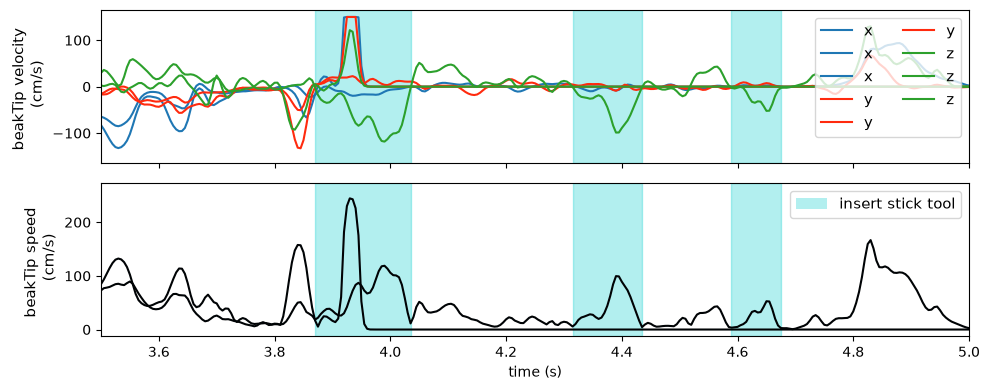

In [24]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

from ethograph.labels.intervals import add_interval, empty_intervals
from ethograph.labels.plots import plot_label_segments

sel = {"keypoint": "beakTip", "individual": "Crow1"}

# 3 labelled intervals (real onsets from the Moll2025 dataset)
label_color = np.array([0, 204, 204]) / 255.0  # _LABEL_COLORS[10]
labels_df = empty_intervals()
labels_df = add_interval(labels_df, 3.87, 4.035, 10, "Crow1")
labels_df = add_interval(labels_df, 4.315, 4.435, 10, "Crow1")
labels_df = add_interval(labels_df, 4.588757756, 4.674700055, 10, "Crow1")

label_mappings = {10: {"name": "stickInDisp", "color": label_color, "order": 10, "branch": 0}}

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

# velocity x, y, z
for i, (axis_name, color) in enumerate(zip(["x", "y", "z"], ["#1f77b4", "#ff2a0e", "#2ca02c"])):
    vel, _ = eto.sel_valid(ds["velocity"].sel(space=axis_name), sel)
    axes[0].plot(ds.time, vel, color=color, label=axis_name)
axes[0].set_ylabel("beakTip velocity \n (cm/s)", fontsize=11)
axes[0].legend(loc="upper right", fontsize=11, ncol=2)
plot_label_segments(axes[0], labels_df, label_mappings, individual="Crow1", is_main=True, alpha=0.3)

# speed
spd, _ = eto.sel_valid(ds["speed"], sel)
axes[1].plot(ds.time, spd, color="#000305")
axes[1].set_ylabel("beakTip speed \n (cm/s)", fontsize=11)
plot_label_segments(axes[1], labels_df, label_mappings, individual="Crow1", is_main=True, alpha=0.3)

axes[1].set_xlabel("time (s)")
insert_stick_patch = mpatches.Patch(
    facecolor=label_color,
    alpha=0.3,
    edgecolor="none",
    label="insert stick tool",
)

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(
    [insert_stick_patch],
    ["insert stick tool"],
    loc="upper right",
    fontsize=11,
    ncol=4,
)

for ax in axes:
    ax.set_xlim(3.5, 5.0)


plt.tight_layout()
plt.show()

## Changepoints

Besides looking at the `z-velocity`, one can also identify good candidates for segmentation boundaries by looking at where there are minima or turning points in the `beakTip` speed curve. We call these kinematic {doc}`changepoints <../advanced/changepoints/index>`.


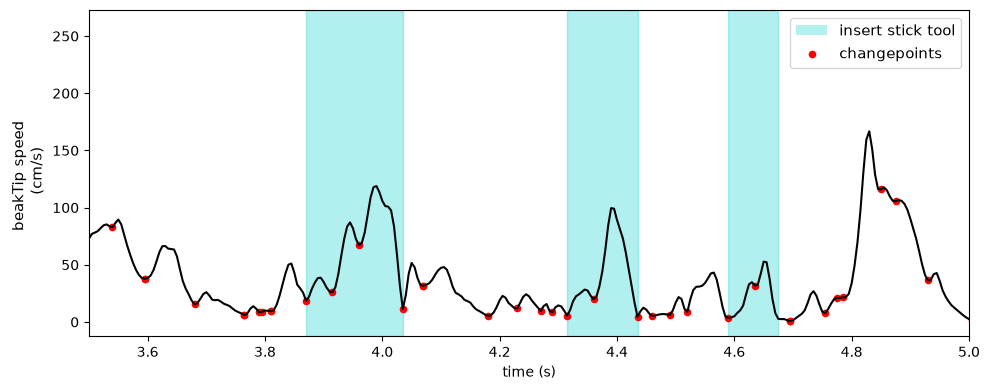

In [32]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

from ethograph.labels.intervals import add_interval, empty_intervals
from ethograph.labels.plots import plot_label_segments

sel = {"keypoints": "beakTip", "individuals": "Crow1"}

# 3 labelled intervals (real onsets from the Moll2025 dataset)
label_color = np.array([0, 204, 204]) / 255.0  # _LABEL_COLORS[10]
labels_df = empty_intervals()
labels_df = add_interval(labels_df, 3.87, 4.035, 10, "Crow1")
labels_df = add_interval(labels_df, 4.315, 4.435, 10, "Crow1")
labels_df = add_interval(labels_df, 4.588757756, 4.674700055, 10, "Crow1")

label_mappings = {10: {"name": "stickInDisp", "color": label_color, "order": 10, "branch": 0}}

fig = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

# speed
spd, _ = eto.sel_valid(ds["speed"], sel)
plt.plot(ds.time, spd, color="#000305")

troughs = ds["speed_troughs"].sel(keypoints="beakTip", individuals="Crow1").values
trough_idx = np.where(troughs == 1)[0]
turning_points = ds["speed_turning_points"].sel(keypoints="beakTip", individuals="Crow1").values
turning_points_idx = np.where(turning_points == 1)[0]
changepoints_idx = np.sort(np.concatenate([trough_idx, turning_points_idx]))
plt.scatter(ds.time[changepoints_idx], spd[changepoints_idx], s=20, c="r", label="changepoints")
plt.ylabel("beakTip speed \n (cm/s)", fontsize=11)
plot_label_segments(plt, labels_df, label_mappings, individual="Crow1", is_main=True, alpha=0.3)

plt.xlabel("time (s)")
insert_stick_patch = mpatches.Patch(
    facecolor=label_color,
    alpha=0.3,
    edgecolor="none",
    label="insert stick tool",
)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    [insert_stick_patch, *handles],
    ["insert stick tool", *labels],
    loc="upper right",
    fontsize=11,
)

plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.show()

## Storing trials: Dataset vs TrialTree

Back at the start we split loading into {ref}`one recording versus trials
<target-data-loading>`. That choice decides how you *load*; this section shows
what it looks like on *disk* for the xarray backend. A `session.nc` can hold
either shape, and the GUI accepts both.

**Plain Dataset** — a single `xr.Dataset` saved with
{func}`xarray.Dataset.to_netcdf`. Loaded as one trial:

```python
import xarray as xr

ds = xr.Dataset(...)
ds.to_netcdf("session.nc")
# -> GUI loads this as one trial
```

**TrialTree** — wraps one `xr.Dataset` per trial into a single `.nc`, and is
how multi-trial data is stored on the xarray side (pynapple uses an
{class}`~pynapple.IntervalSet`; NWB uses its `nwb.trials` table):

```python
import ethograph as eto

# Multiple trials: one Dataset per trial
dt = eto.from_datasets([ds_trial1, ds_trial2, ds_trial3])
dt.save("session.nc")

# Access individual trials
ds = dt.trial(1)      # by ID
ds = dt.itrial(0)     # by index
```

Already have one session-long `xr.Dataset`? You don't have to rebuild it by
hand — {ref}`from_continuous() <target-from-continuous>` carves trial windows
out of it.

Storing trials is only half the job: the GUI also needs to know which video,
audio and pose files belong to each trial, which lives in a separate alignment
file. {doc}`preparing_data` covers both ends — the dataset schema and the
alignment — and {doc}`../api/trialtree` documents the full TrialTree API.


(target-templates)=
## Template datasets

Ready-made datasets with video, features and labels already in place, downloaded
from the start page. The notebooks that built them are in the
{ref}`examples gallery <target-examples-gallery>`.

**Tool-using crows (Moll et al., 2025)** — Learned precision tool use in carrion crows. Two trials with video, 3D pose (DeepLabCut), kinematics, and video features.

**Lockbox (Reiske et al., 2026)** — Behaviour recognition for mice solving mechanical puzzle lockboxes. Six trials with multi-camera video and pose.

**Zebra finches in BirdPark (Rüttimann et al., 2025)** — Multimodal dataset of zebra finch groups with synchronized video, microphone arrays, and backpack-mounted accelerometers.

**Cricket stridulation** — Sound production in *Pholidoptera littoralis* with synchronized video, audio, and DeepLabCut pose.


### References

Moll, F. W., Würzler, J., & Nieder, A. (2025). Learned precision tool use in carrion crows. *Current Biology*, 35(19), 4845–4852.e3. https://doi.org/10.1016/j.cub.2025.08.033

Reiske, P., Boon, M. N., Andresen, N., Traverso, S., Daniels, M., Hohlbaum, K., Lewejohann, L., Thöne-Reineke, C., Hellwich, O., & Sprekeler, H. (2026). Mouse Lockbox Dataset: Behavior Recognition for Mice Solving Lockboxes. *International Journal of Computer Vision*, 134, 318. https://doi.org/10.1007/s11263-026-02908-x

Rüttimann, L., Wang, Y., Rychen, J., Tomka, T., Hörster, H., & Hahnloser, R. H. R. (2025). Multimodal system for recording individual-level behaviors in songbird groups. *PeerJ*, 13, e20203. https://doi.org/10.7717/peerj.20203
